In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
df=pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
df.shape

(1338, 7)

EDA STEPS

In [4]:
df.head

<bound method NDFrame.head of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [10]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

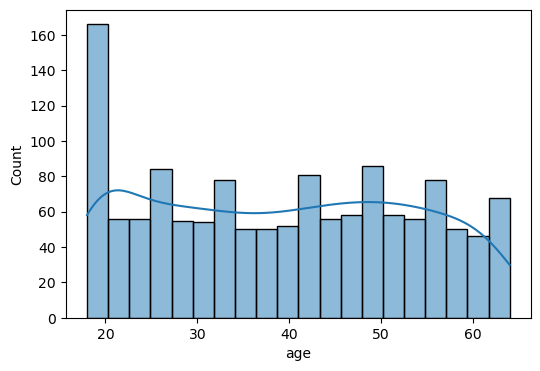

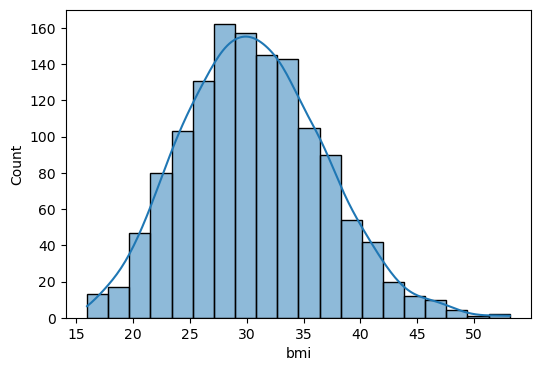

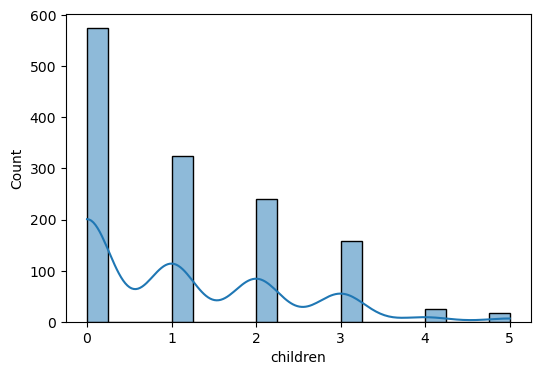

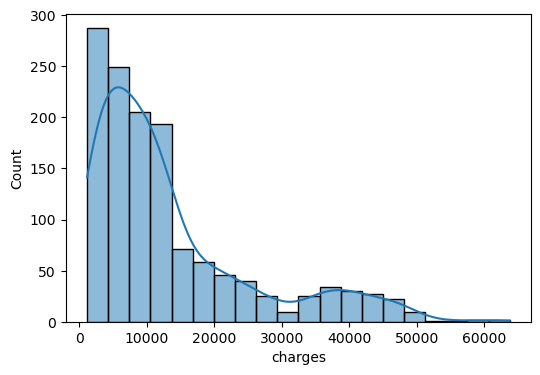

In [11]:
numeric_columns=['age', 'bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)

<Axes: xlabel='children', ylabel='count'>

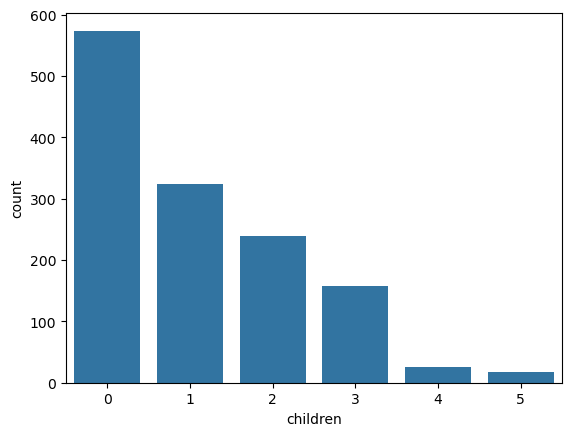

In [16]:
sns.countplot(x=df['children'])

<Axes: xlabel='smoker', ylabel='count'>

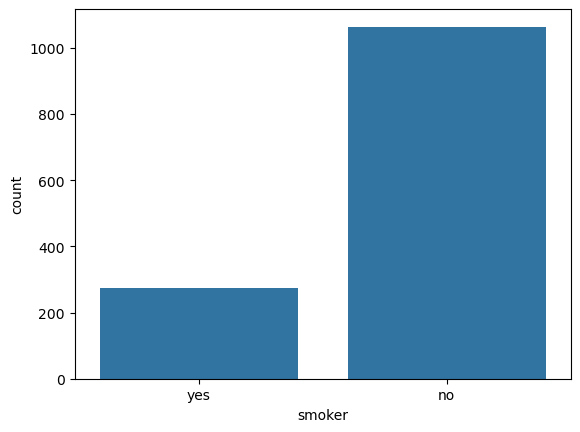

In [17]:
sns.countplot(x=df['smoker'])

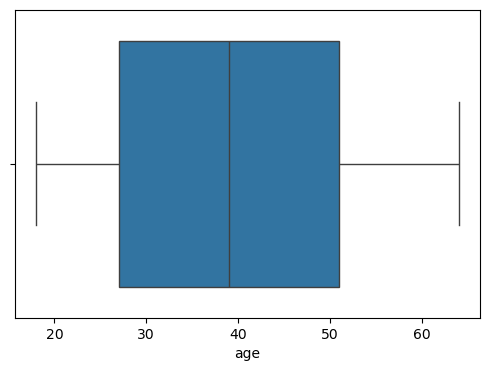

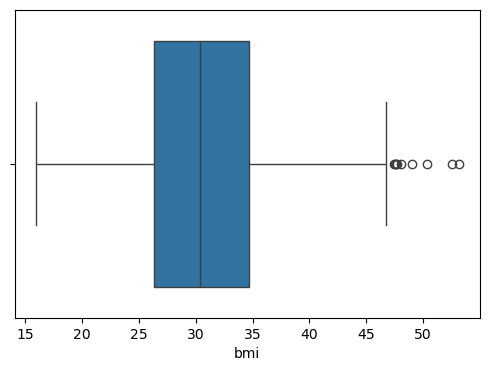

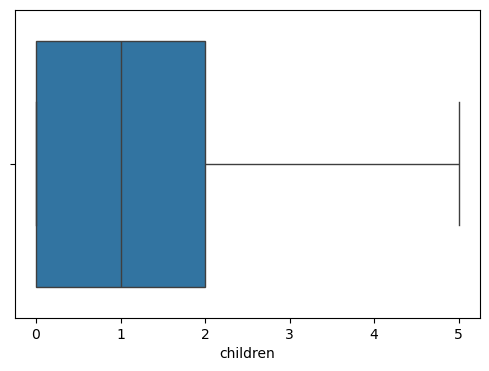

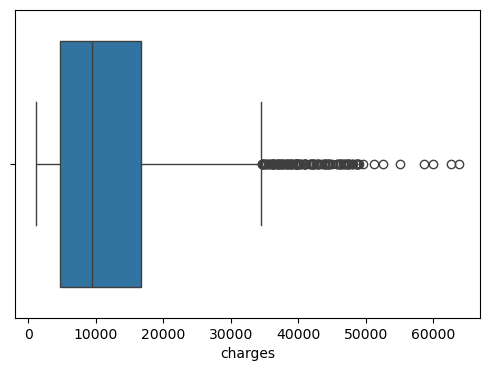

In [18]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])

<Axes: >

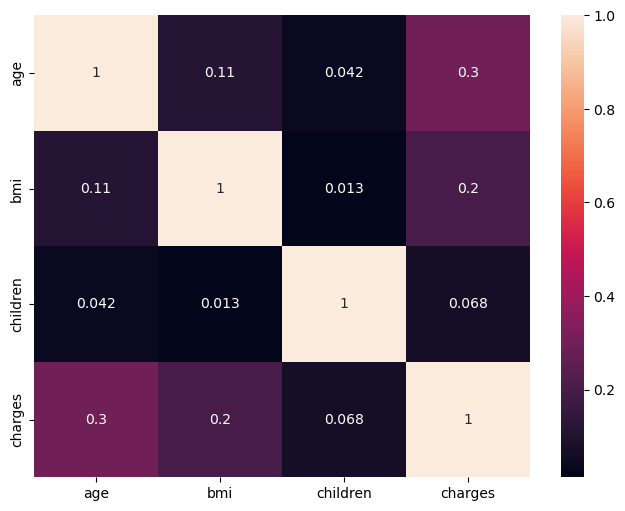

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [23]:
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1 

outliers = ((df < (Q1 - 1.5*IQR)) | (df > (Q3 + 1.5*IQR))).sum()

print(outliers)

ValueError: Operands are not aligned. Do `left, right = left.align(right, axis=1, copy=False)` before operating.

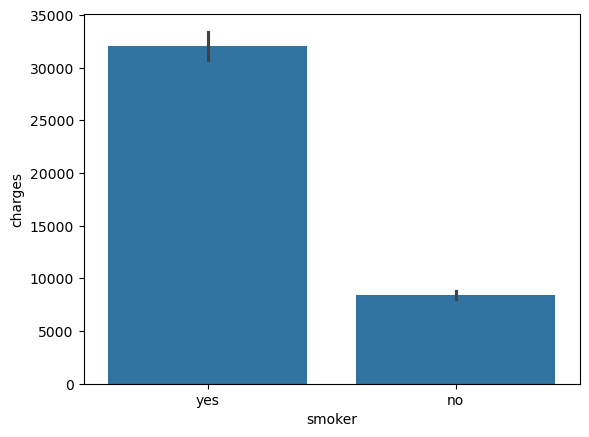

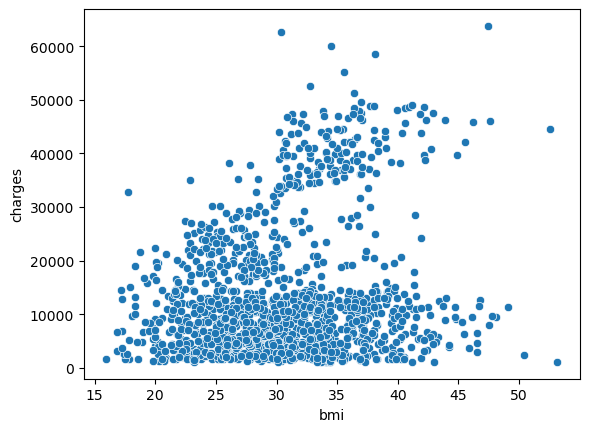

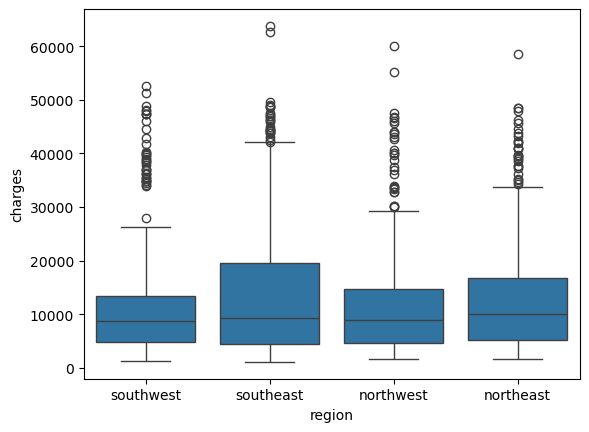

In [24]:
sns.barplot(x='smoker', y='charges', data=df)
plt.show()

sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

sns.boxplot(x='region', y='charges', data=df)
plt.show()

In [25]:
df.groupby("region")["charges"].mean()


region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

Data cleaning and preprocessing


In [26]:
df_cleaned=df.copy()
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [29]:
df_cleaned.shape

(1337, 7)

In [27]:
df_cleaned.drop_duplicates(inplace =True)

In [28]:
df_cleaned.shape

(1337, 7)

In [30]:
df_cleaned.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [31]:
df_cleaned.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [33]:
df_cleaned['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [34]:
df_cleaned['sex']=df_cleaned['sex'].map({'male':0,'female':1})

In [35]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [36]:
df_cleaned['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [37]:
df_cleaned['smoker']=df_cleaned['smoker'].map({'no':0,'yes':1})

In [38]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [39]:
df_cleaned.rename(columns={'sex':'is_female','smoker':'is_smoker'},inplace=True)

In [40]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


In [43]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [44]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['region'],drop_first=True)

In [45]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,1,16884.92400,False,False,True
1,18,0,33.770,1,0,1725.55230,False,True,False
2,28,0,33.000,3,0,4449.46200,False,True,False
3,33,0,22.705,0,0,21984.47061,True,False,False
4,32,0,28.880,0,0,3866.85520,True,False,False


feature engineering and extraction

<Axes: xlabel='bmi', ylabel='Count'>

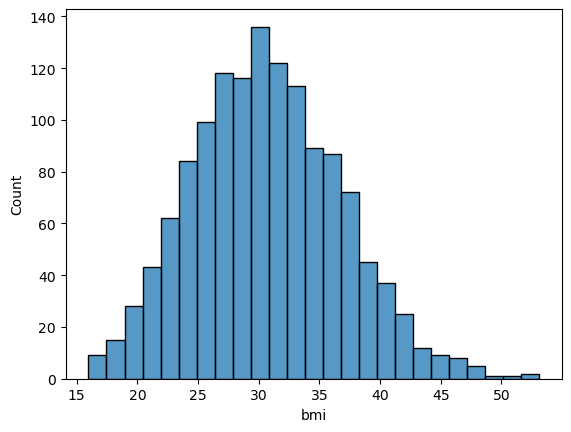

In [47]:
sns.histplot(df['bmi'])

In [50]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,normal


In [49]:
df_cleaned['bmi_category']=pd.cut(df_cleaned['bmi'],
                                 bins=[0,18.5,25.9,29.9,float('inf')],
                                 labels=['underweight','normal','overweight','obese'])


In [53]:
region_cols = ['region_northwest', 'region_southeast', 'region_southwest']

df[region_cols] = df[region_cols].astype(int)

KeyError: "None of [Index(['region_northwest', 'region_southeast', 'region_southwest'], dtype='object')] are in the [columns]"

In [54]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,False,False,True,overweight
1,18,0,33.770,1,0,1725.55230,False,True,False,obese
2,28,0,33.000,3,0,4449.46200,False,True,False,obese
3,33,0,22.705,0,0,21984.47061,True,False,False,normal
4,32,0,28.880,0,0,3866.85520,True,False,False,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,True,False,False,obese
1334,18,1,31.920,0,0,2205.98080,False,False,False,obese
1335,18,1,36.850,0,0,1629.83350,False,True,False,obese
1336,21,1,25.800,0,0,2007.94500,False,False,True,normal


In [56]:
print(df.columns)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [57]:
print(df_cleaned.columns)

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category'],
      dtype='object')


In [59]:
df_cleaned.dtypes

age                    int64
is_female              int64
bmi                  float64
children               int64
is_smoker              int64
charges              float64
region_northwest        bool
region_southeast        bool
region_southwest        bool
bmi_category        category
dtype: object

In [60]:
bool_cols = ['region_northwest', 'region_southeast', 'region_southwest']

df_cleaned[bool_cols] = df_cleaned[bool_cols].replace({True: 1, False: 0})

In [61]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27.900,0,1,16884.92400,0,0,1,overweight
1,18,0,33.770,1,0,1725.55230,0,1,0,obese
2,28,0,33.000,3,0,4449.46200,0,1,0,obese
3,33,0,22.705,0,0,21984.47061,1,0,0,normal
4,32,0,28.880,0,0,3866.85520,1,0,0,overweight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,obese
1334,18,1,31.920,0,0,2205.98080,0,0,0,obese
1335,18,1,36.850,0,0,1629.83350,0,1,0,obese
1336,21,1,25.800,0,0,2007.94500,0,0,1,normal


In [62]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)

In [66]:
df_cleaned=df_cleaned.astype(int)

In [64]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,1,False,True,False
1,18,0,33.770,1,0,1725.55230,0,1,0,False,False,True
2,28,0,33.000,3,0,4449.46200,0,1,0,False,False,True
3,33,0,22.705,0,0,21984.47061,1,0,0,True,False,False
4,32,0,28.880,0,0,3866.85520,1,0,0,False,True,False


In [65]:
df_cleaned


,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27.900,0,1,16884.92400,0,0,1,False,True,False
1,18,0,33.770,1,0,1725.55230,0,1,0,False,False,True
2,28,0,33.000,3,0,4449.46200,0,1,0,False,False,True
3,33,0,22.705,0,0,21984.47061,1,0,0,True,False,False
4,32,0,28.880,0,0,3866.85520,1,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,0,10600.54830,1,0,0,False,False,True
1334,18,1,31.920,0,0,2205.98080,0,0,0,False,False,True
1335,18,1,36.850,0,0,1629.83350,0,1,0,False,False,True
1336,21,1,25.800,0,0,2007.94500,0,0,1,True,False,False


In [67]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


feature scaling

In [68]:
df_cleaned.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')

In [72]:
from sklearn.preprocessing import StandardScaler

cols = ['age', 'bmi', 'children']

scaler = StandardScaler()

df_cleaned[cols] = scaler.fit_transform(df_cleaned[cols])

In [73]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest,bmi_category_normal,bmi_category_overweight,bmi_category_obese
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,0,1,0,1,0
1,-1.511647,0,0.462463,-0.079442,0,1725,0,1,0,0,0,1
2,-0.799350,0,0.462463,1.580143,0,4449,0,1,0,0,0,1
3,-0.443201,0,-1.334960,-0.909234,0,21984,1,0,0,1,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,1,0,0,0,0,1
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0,0,0,0,1
1335,-1.511647,1,0.952670,-0.909234,0,1629,0,1,0,0,0,1
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0,1,1,0,0


In [77]:
from scipy.stats import pearsonr
import pandas as pd

# ----------------------------------------
# Pearson Correlation Calculation
# ----------------------------------------

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df = correlation_df.sort_values(
    by='Pearson Correlation',
    ascending=False
)

print(correlation_df)

                    Feature  Pearson Correlation
4                 is_smoker             0.787234
0                       age             0.298309
10       bmi_category_obese             0.197660
1                       bmi             0.196236
6          region_southeast             0.073577
2                  children             0.067390
5          region_northwest            -0.038695
7          region_southwest            -0.043637
3                 is_female            -0.058046
9   bmi_category_overweight            -0.101718
8       bmi_category_normal            -0.120300


In [76]:
print(df_cleaned.columns)

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'charges',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'],
      dtype='object')


In [78]:
from scipy.stats import pearsonr
import pandas as pd

# ----------------------------------------
# Pearson Correlation Calculation
# ----------------------------------------

selected_features = [
    'age', 'bmi', 'children', 'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df = correlation_df.sort_values(
    by='Pearson Correlation',
    ascending=False
)

print(correlation_df)

                    Feature  Pearson Correlation
4                 is_smoker             0.787234
0                       age             0.298309
10       bmi_category_obese             0.197660
1                       bmi             0.196236
6          region_southeast             0.073577
2                  children             0.067390
5          region_northwest            -0.038695
7          region_southwest            -0.043637
3                 is_female            -0.058046
9   bmi_category_overweight            -0.101718
8       bmi_category_normal            -0.120300


In [79]:
cat_features = [
    'is_female', 'is_smoker',
    'region_northwest', 'region_southeast', 'region_southwest',
    'bmi_category_normal', 'bmi_category_overweight', 'bmi_category_obese'
]

from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05

df_cleaned['charges_bin'] = pd.qcut(df_cleaned['charges'], q=4, labels=False)

chi2_results = {}

for col in cat_features:
    contingency = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')

chi2_df

,chi2_statistic,p_value,Decision
is_smoker,848.219178,0.0,Reject Null (Keep Feature)
region_southeast,15.998167,0.001135,Reject Null (Keep Feature)
is_female,10.258784,0.01649,Reject Null (Keep Feature)
bmi_category_obese,7.654464,0.05372,Accept Null (Drop Feature)
region_southwest,5.091893,0.165191,Accept Null (Drop Feature)
bmi_category_normal,4.185753,0.242092,Accept Null (Drop Feature)
bmi_category_overweight,2.525894,0.47063,Accept Null (Drop Feature)
region_northwest,1.13424,0.768815,Accept Null (Drop Feature)


In [80]:
final_df = df_cleaned[[
    'age',
    'is_female',
    'bmi',
    'children',
    'is_smoker',
    'charges',
    'region_southeast',
    'bmi_category_overweight'
]]

In [81]:
final_df

,age,is_female,bmi,children,is_smoker,charges,region_southeast,bmi_category_overweight
0,-1.440418,1,-0.517949,-0.909234,1,16884,0,1
1,-1.511647,0,0.462463,-0.079442,0,1725,1,0
2,-0.799350,0,0.462463,1.580143,0,4449,1,0
3,-0.443201,0,-1.334960,-0.909234,0,21984,0,0
4,-0.514431,0,-0.354547,-0.909234,0,3866,0,1
...,...,...,...,...,...,...,...,...
1333,0.767704,0,-0.027743,1.580143,0,10600,0,0
1334,-1.511647,1,0.135659,-0.909234,0,2205,0,0
1335,-1.511647,1,0.952670,-0.909234,0,1629,1,0
1336,-1.297958,1,-0.844753,-0.909234,0,2007,0,0
